In [1]:
#####################################################
# Imports and Simulation IO
#####################################################

from MDToolkit.IO.read_file import lammps_data_file_to_structured_system, lammps_dump_file_to_simulation
from MDToolkit.data.objects import Simulation, StructuredSystem
from MDToolkit.data.misc_objects import BoxVolume, CylinderVolume, get_max_box_volume_from_simulation
from MDToolkit.analysis.velocity import radial_velocity_profile_time_averaged

cyl = CylinderVolume([-24.56, 0, 0], [24.56, 0, 0], 10.5)

file_path = "/media/jrjoseph/Elements/projects/training/cnt_water_ls6/v_profile_calculation/cnt1616_water_nvt_prod.out"

type_dict = {
    1 : "O",
    2 : "C",
    3 : "H"
}

simulation = lammps_dump_file_to_simulation(file_path, type_dict)


Processing frames:   0%|          | 0/4001 [00:00<?, ?frame(s)/s]

In [2]:
#####################################################
# Plotting Functions
#####################################################

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


def plot_radial_velocity_profile(
    velocity_data,
    show_std=True,
    figsize=(8, 5),
    axes=None,
    x_major=2,
    x_minor=0.5,
    y_major=None,
    y_minor=None,
):
    """
    Plot time-averaged radial velocity profiles.

    Two plots are produced:
        1. vx, vy, and vz on a shared axis (if present)
        2. Speed on a separate axis (if present)

    Parameters
    ----------
    velocity_data : dict
        Output from radial_velocity_profile_time_averaged().
    show_std : bool, optional
        If True, shade the ±1σ region.
    figsize : tuple, optional
        Figure size for each plot.
    axes : tuple(ax_components, ax_speed), optional
        Existing matplotlib axes.
    x_major, x_minor : float or None
        Major and minor tick spacing for the x-axis.
    y_major, y_minor : float or None
        Major and minor tick spacing for the y-axis.
    """

    r = velocity_data["bin_centers"]

    component_info = {
        "vx": (r"$\langle v_x \rangle$", "C0"),
        "vy": (r"$\langle v_y \rangle$", "C1"),
        "vz": (r"$\langle v_z \rangle$", "C2"),
    }

    # Create axes if necessary
    if axes is None:
        _, ax_components = plt.subplots(figsize=figsize)
        _, ax_speed = plt.subplots(figsize=figsize)
    else:
        ax_components, ax_speed = axes

    def _format_axis(ax, ylabel):
        """Apply consistent formatting to an axis."""
        ax.set_xlabel(r"Radius ($\AA$)")
        ax.set_ylabel(ylabel)

        ax.tick_params(
            direction="in",
            which="both",
            top=True,
            right=True,
        )

        ax.minorticks_on()
        ax.margins(x=0.02)

        if x_major is not None:
            ax.xaxis.set_major_locator(MultipleLocator(x_major))
        if x_minor is not None:
            ax.xaxis.set_minor_locator(MultipleLocator(x_minor))
        if y_major is not None:
            ax.yaxis.set_major_locator(MultipleLocator(y_major))
        if y_minor is not None:
            ax.yaxis.set_minor_locator(MultipleLocator(y_minor))

        ax.legend(frameon=False)
        ax.figure.tight_layout()

    ############################################################
    # Cartesian velocity components
    ############################################################

    plotted = False

    for comp, (label, color) in component_info.items():
        if comp not in velocity_data:
            continue

        mean = velocity_data[comp]

        ax_components.plot(
            r,
            mean,
            lw=2,
            color=color,
            label=label,
        )

        if show_std and f"{comp}_std" in velocity_data:
            std = velocity_data[f"{comp}_std"]

            ax_components.fill_between(
                r,
                mean - std,
                mean + std,
                color=color,
                alpha=0.20,
            )

        plotted = True

    if plotted:
        _format_axis(
            ax_components,
            r"Velocity Component ($\AA$/fs)",
        )

    ############################################################
    # Speed
    ############################################################

    if "speed" in velocity_data:

        mean = velocity_data["speed"]

        ax_speed.plot(
            r,
            mean,
            lw=2,
            color="k",
            label=r"$\langle |\mathbf{v}| \rangle$",
        )

        if show_std and "speed_std" in velocity_data:
            std = velocity_data["speed_std"]

            ax_speed.fill_between(
                r,
                mean - std,
                mean + std,
                color="k",
                alpha=0.20,
            )

        _format_axis(
            ax_speed,
            r"Speed ($\AA$/fs)",
        )

    return ax_components, ax_speed

In [3]:
v_prof = radial_velocity_profile_time_averaged(simulation, cyl, bins = 25)

Performing velocity profile calculations:: 100%|██████████| 4001/4001 [01:28<00:00, 45.35frame(s)/s]
/workspace/code/MDToolkit/MDToolkit/analysis/velocity.py:116: RuntimeWarning: Mean of empty slice
  "vx": np.nanmean(vx, axis=0),
/oden/jrjoseph/.local/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/workspace/code/MDToolkit/MDToolkit/analysis/velocity.py:118: RuntimeWarning: Mean of empty slice
  "vy": np.nanmean(vy, axis=0),
/workspace/code/MDToolkit/MDToolkit/analysis/velocity.py:120: RuntimeWarning: Mean of empty slice
  "vz": np.nanmean(vz, axis=0),
/workspace/code/MDToolkit/MDToolkit/analysis/velocity.py:122: RuntimeWarning: Mean of empty slice
  "speed": np.nanmean(speed, axis=0),


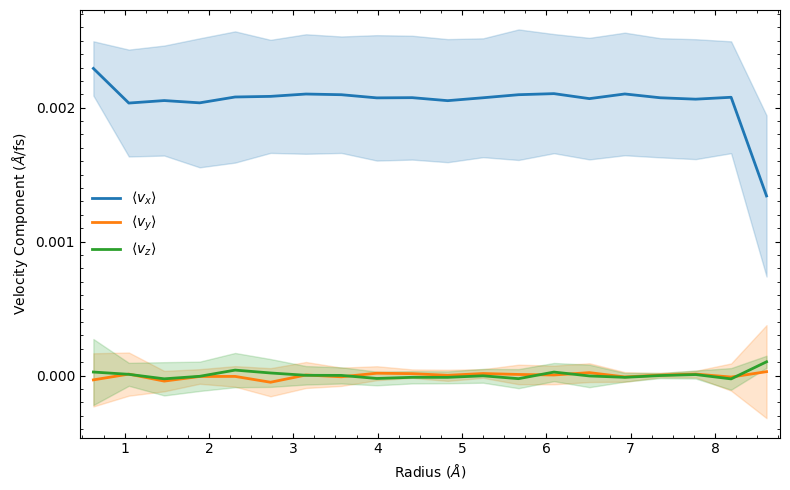

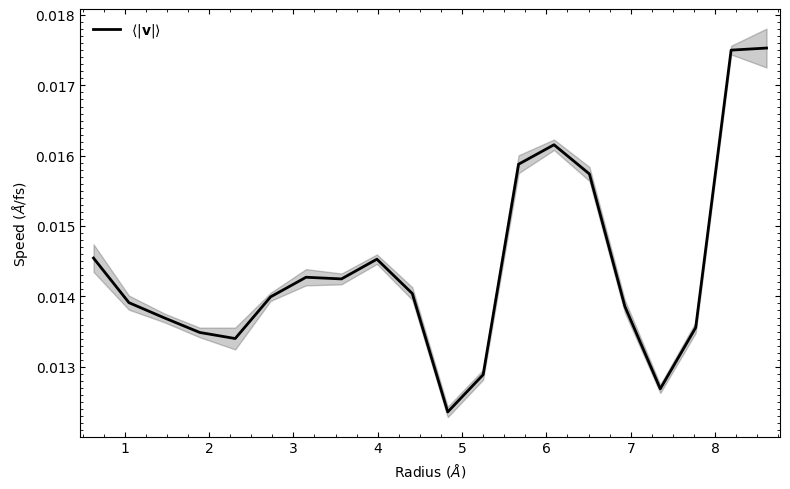

In [7]:
plot_radial_velocity_profile(
    v_prof,
    x_major=1.0,
    x_minor=0.25,
    y_major=0.001,
    y_minor=0.0001,
)

plt.show()

In [5]:
print(np.nanmedian(v_prof["vx"]) * 100000)

207.46389479074494
